<a href="https://colab.research.google.com/github/kerichhezron-source/Machine-Learning-Projects-/blob/main/Hezron's_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


This cell imports the `pandas` library, commonly used for data manipulation and analysis, and the `numpy` library, essential for numerical operations.

In [ ]:
df = pd.read_csv('/content/Iris.csv')
df.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


This code loads the 'Iris.csv' dataset into a pandas DataFrame named `df`. The `df.head(10)` command then displays the first 10 rows of this DataFrame, allowing for a quick preview of the data structure and content.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from keras.datasets import mnist

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import ShuffleSplit


from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from sklearn.pipeline import Pipeline


This cell imports a comprehensive set of libraries required for machine learning tasks. It includes `pandas` and `numpy` for data handling, `matplotlib.pyplot` and `seaborn` for data visualization, and various modules from `sklearn` for model building (Bagging, Random Forest, Decision Tree), data splitting and cross-validation, performance metrics (accuracy, confusion matrix, classification report), and pipeline creation.

In [ ]:
from sklearn import datasets
iris = datasets.load_iris()

This code imports the `datasets` module from `sklearn` and then loads the classic Iris dataset, which is a built-in dataset commonly used for classification examples, into the `iris` object.

In [ ]:
print(iris.target_names)
print(iris.feature_names)

['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


This cell prints the names of the target classes (species of Iris flowers) and the names of the features ( sepal length, petal width) available in the Iris dataset.

In [ ]:
print(iris.data[0])
print(iris.target)

[5.1 3.5 1.4 0.2]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


This code prints the feature values of the very first sample in the `iris.data` array and then prints all the target labels (`iris.target`) for the entire dataset.

In [ ]:
data=pd.DataFrame({
    'sepal length':iris.data[:,0],
    'sepal width':iris.data[:,1],
    'petal length':iris.data[:,2],
    'petal width':iris.data[:,3],
    'species':iris.target
})
data.head()

,sepal length,sepal width,petal length,petal width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


This cell constructs a new pandas DataFrame called `data`. It combines the feature data (`iris.data`) and the target species (`iris.target`) into a single structured table with clear column names. `data.head()` then displays the initial rows of this newly created DataFrame.

In [ ]:
from sklearn.model_selection import train_test_split
X=data[['sepal length', 'sepal width', 'petal length', 'petal width']]
y=data['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

This code prepares the data for machine learning by separating the features (independent variables, `X`) from the target variable (dependent variable, `y`). It then splits these into training (`X_train`, `y_train`) and testing (`X_test`, `y_test`) sets, with 30% of the data reserved for testing the model's performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf=RandomForestClassifier(n_estimators=100)
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)

This cell initializes a `RandomForestClassifier` with 100 decision trees (`n_estimators=100`). It then trains this classifier using the training features (`X_train`) and training labels (`y_train`), and finally uses the trained model to make predictions (`y_pred`) on the unseen test features (`X_test`).

In [ ]:
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9555555555555556


This code imports the `metrics` module from `sklearn` and then calculates and prints the accuracy score of the model's predictions (`y_pred`) compared to the actual target labels of the test set (`y_test`).

In [ ]:
feature_imp = pd.Series(clf.feature_importances_,index=iris.feature_names).sort_values(ascending=False)
feature_imp

,0
petal width (cm),0.460535
petal length (cm),0.432225
sepal length (cm),0.081502
sepal width (cm),0.025738


This cell extracts the feature importances from the trained `RandomForestClassifier`. It converts these importances into a pandas Series, using the original feature names as the index, and then sorts them in descending order to easily identify the most influential features.

/tmp/ipykernel_2639/807991197.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


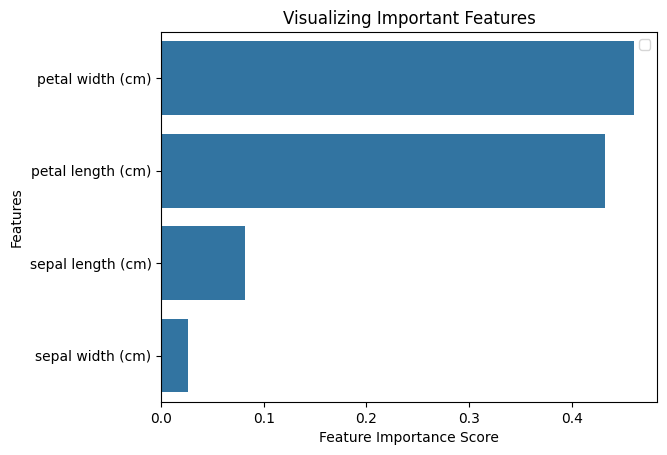

In [ ]:
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features")
plt.legend()
plt.show()

This code generates a bar plot using `seaborn` to visually represent the feature importance scores. The `plt.xlabel`, `plt.ylabel`, and `plt.title` functions add descriptive labels and a title to the plot, making it easy to understand which features contribute most to the model's predictions. The `plt.legend()` call without specific labels might produce a warning but typically allows for the plot to be shown.

In [ ]:
X=data[['petal length', 'petal width','sepal length']]
y=data['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

Based on the feature importance analysis, this cell redefines the feature set `X` to include only the most important features: 'petal length', 'petal width', and 'sepal length'. The target `y` remains 'species'. The data is then re-split into new training and testing sets, reflecting this reduced feature set, for subsequent model training and evaluation.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf=RandomForestClassifier(n_estimators=100)
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


Similar to the previous modeling step, this cell initializes another `RandomForestClassifier` with 100 estimators. It trains this new model using the updated training data (`X_train`, `y_train`) which now contains only the most important features. Finally, it makes predictions on the new test set (`X_test`) and prints the accuracy score of this refined model.